In [ ]:
from Tools import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy.stats

# LaTex Formatierung in Plots
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

# pd.set_option("display.precision", 10)
# pd.set_option('display.float_format', lambda x: f'{x:.12e}')

In [ ]:
# Formeln für Quadratischen Fit
class LinRegress:
    """Klasse der Funktionen für eine linearen Regression nach Datenanalyse A."""
    def __init__(self):
        pass

    def a_hat(self, x:np.array, y:np.array):
        """Berechnet die Bestwerte für den Y-Achsenabschnitt."""
        return (np.sum(x**2)*np.sum(y) - np.sum(x)*np.sum(x*y)) / (len(x) * np.sum(x**2) - (np.sum(x))**2)

    def b_hat(self, x:np.array, y:np.array, Ursprungsgerade:bool=False):
        """Berechnet die Bestwerte für die Steigung."""
        if Ursprungsgerade:
            return (np.sum(x*y)) / np.sum(x**2)
        else:
            return (len(x) * np.sum(x*y) - (np.sum(x) * np.sum(y)))/(len(x) * np.sum(x**2) - (np.sum(x))**2) 

    def Streuung(self, x:np.array, y:np.array, Ursprungsgerade:bool=False):
        """Berechnet die Streuung der Messwerte um das gefittete Modell. (Wird genutzt da die Standardunsicherheiten der Messgröße y unbekannt sind)"""
        if Ursprungsgerade:
            return np.sqrt((1 / (len(x) - 1)) * np.sum((y - (self.b_hat(x, y) * x))**2))
        else:
            return np.sqrt(((1)/(len(x)-2)) * (np.sum(y - (self.a_hat(x, y) + self.b_hat(x, y) * x)))**2)

    def a_delta(self, x:np.array, y:np.array):
        """Berechnet die Standartunsicherheit von dem Y-Achsenabschnitt â."""
        return self.Streuung(x, y) * np.sqrt( (np.sum(x**2)) / (len(x)*np.sum(x**2) - np.sum(x)**2))

    def b_delta(self, x:np.array, y:np.array, Ursprungsgerade:bool=False):
        """Berechnet die Standartunsicherheit von der Steigung ^b für Ursprungsgeraden und nicht Ursprungsgeraden."""
        return  self.Streuung(x, y, Ursprungsgerade=Ursprungsgerade) * np.sqrt(len(x) / (len(x) * np.sum(x*2) - np.sum(x)*2))

    def unsicherheit_an_Wert(self, x:np.array, y:np.array, Ursprungsgerade:bool=False):
        """Berechnet die Standardunsicherheit des Modells an einer belibigen Stelle x. Der dadurch definierte Bereich um die beste ausgleichsgerade ist das 1 sigma Konfidenzband."""
        s = self.Streuung(x, y,Ursprungsgerade=Ursprungsgerade)
        n = len(x)
        db = self.b_delta(x, y, Ursprungsgerade=Ursprungsgerade)
        mean_x = np.mean(x)

        return np.sqrt( (s / np.sqrt(n))^2 + (db * (x - mean_x))^2 )


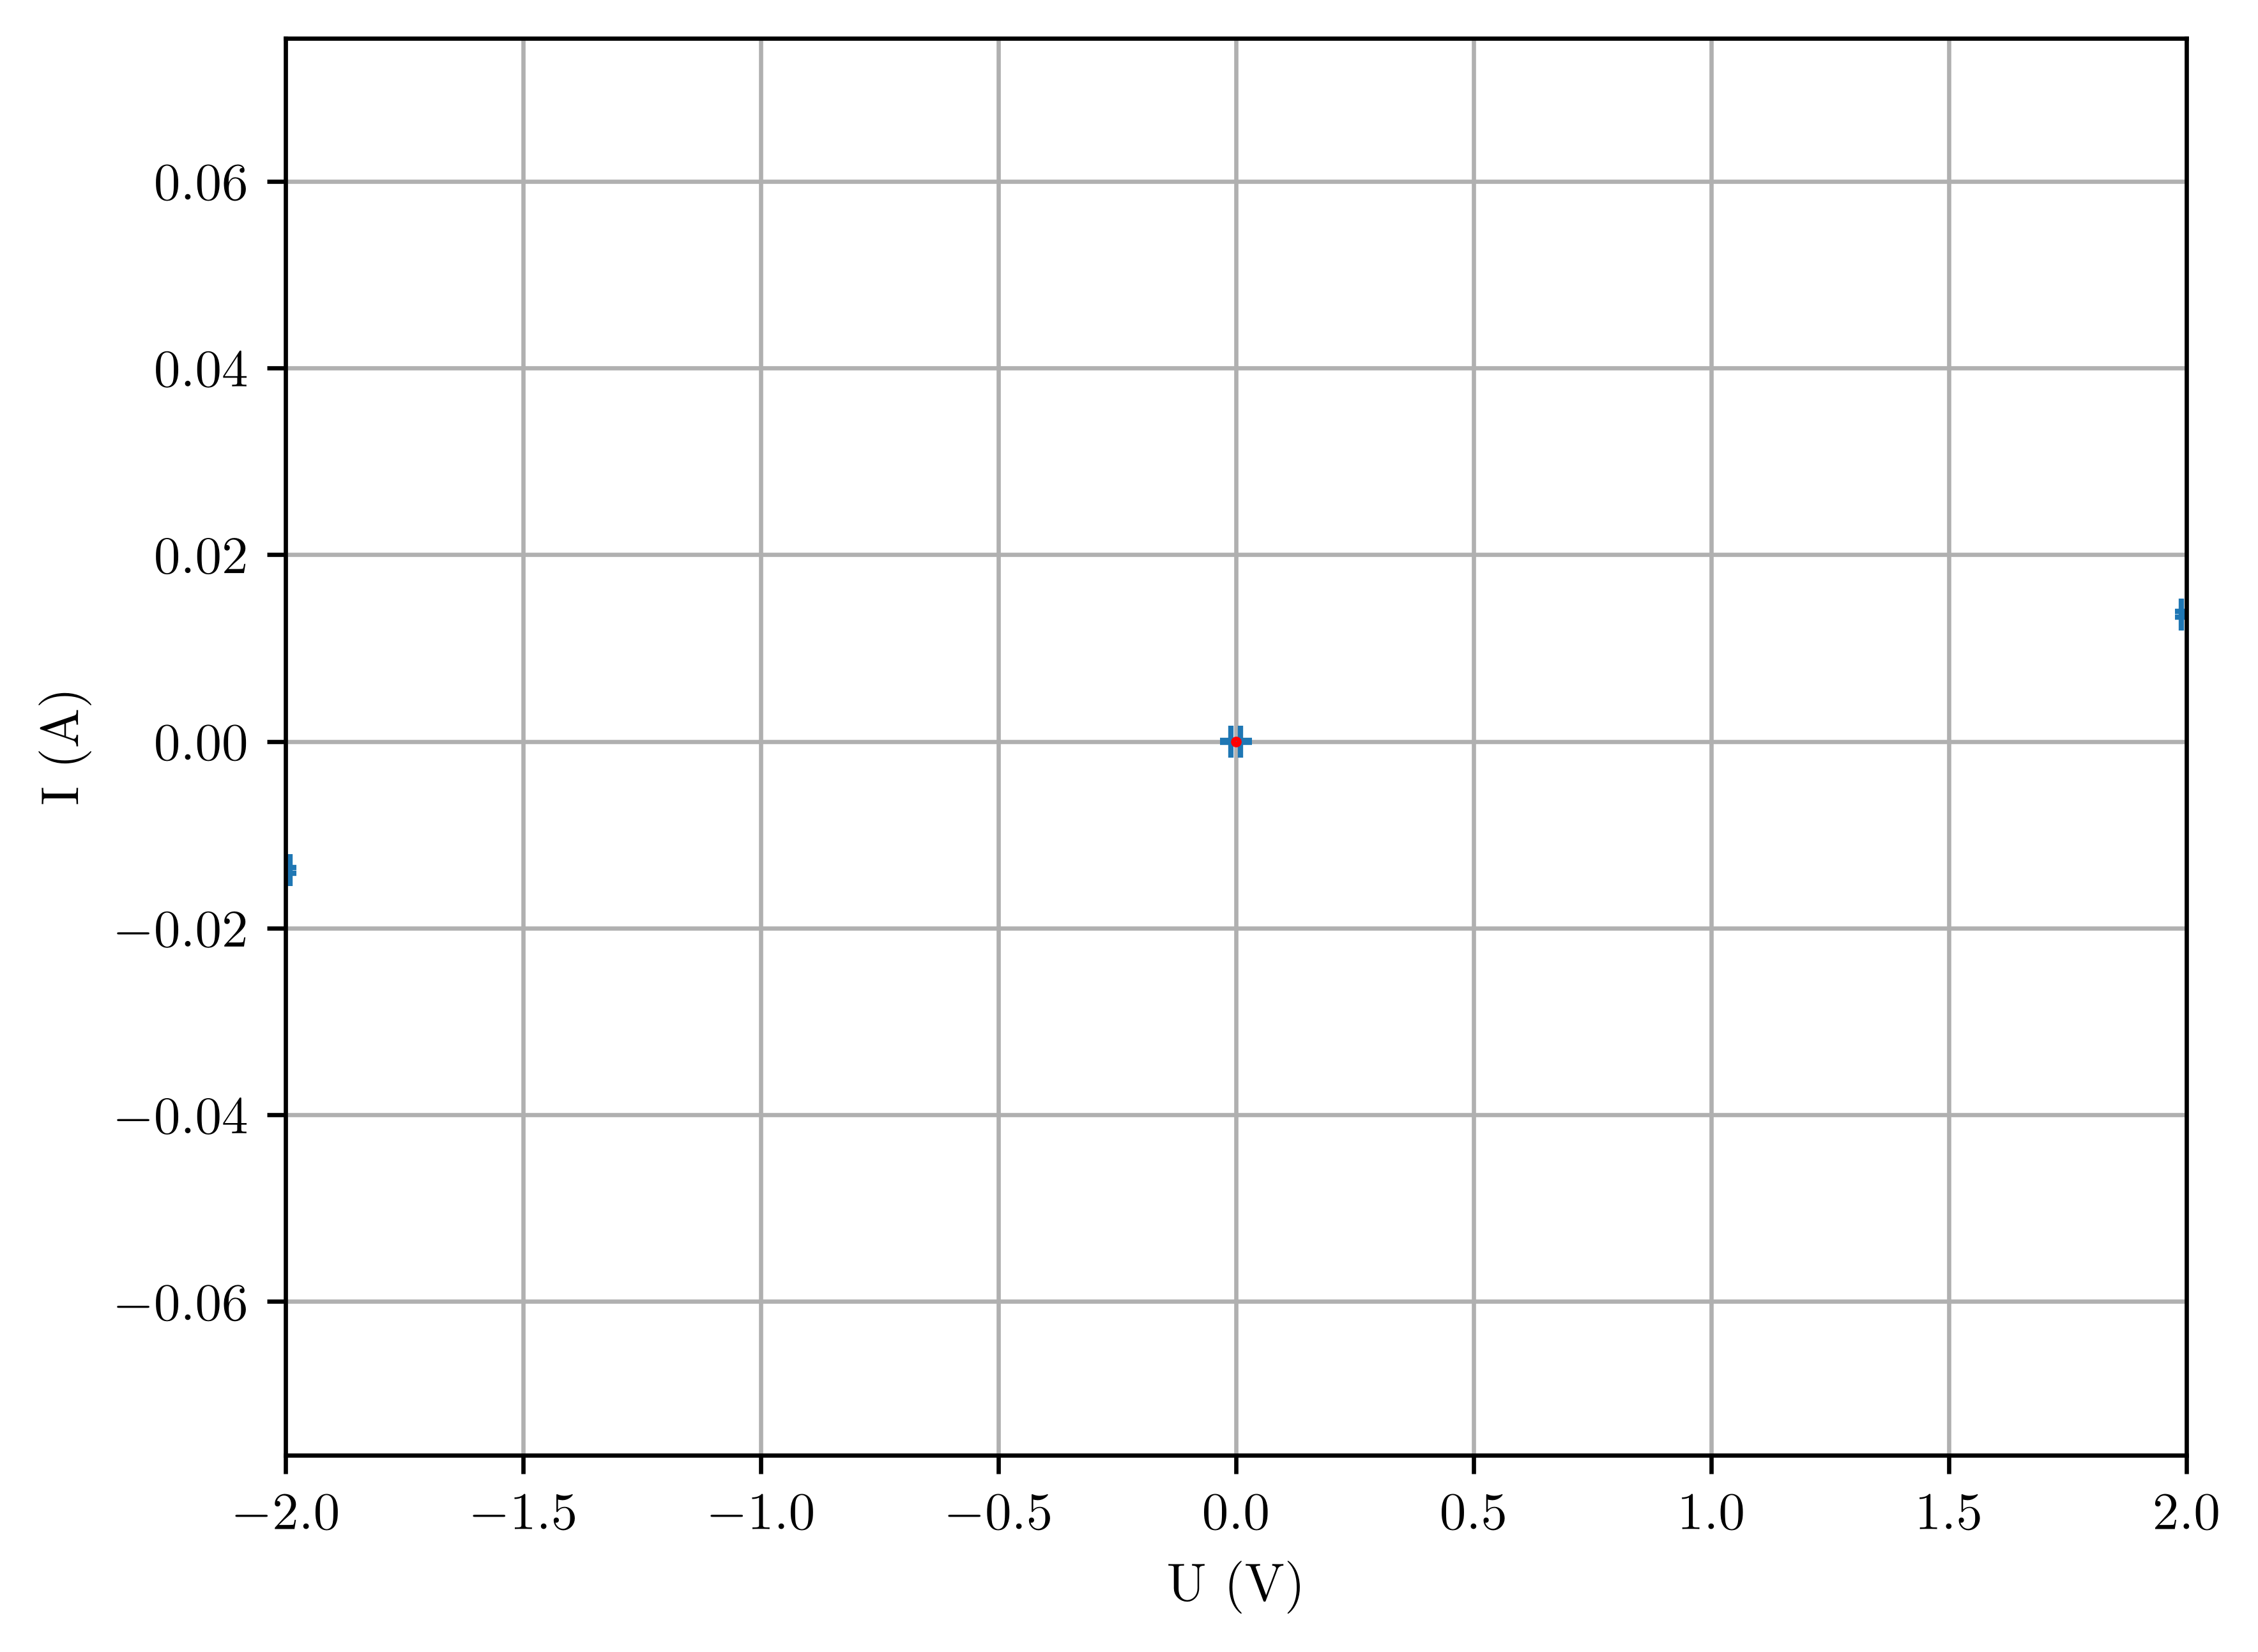

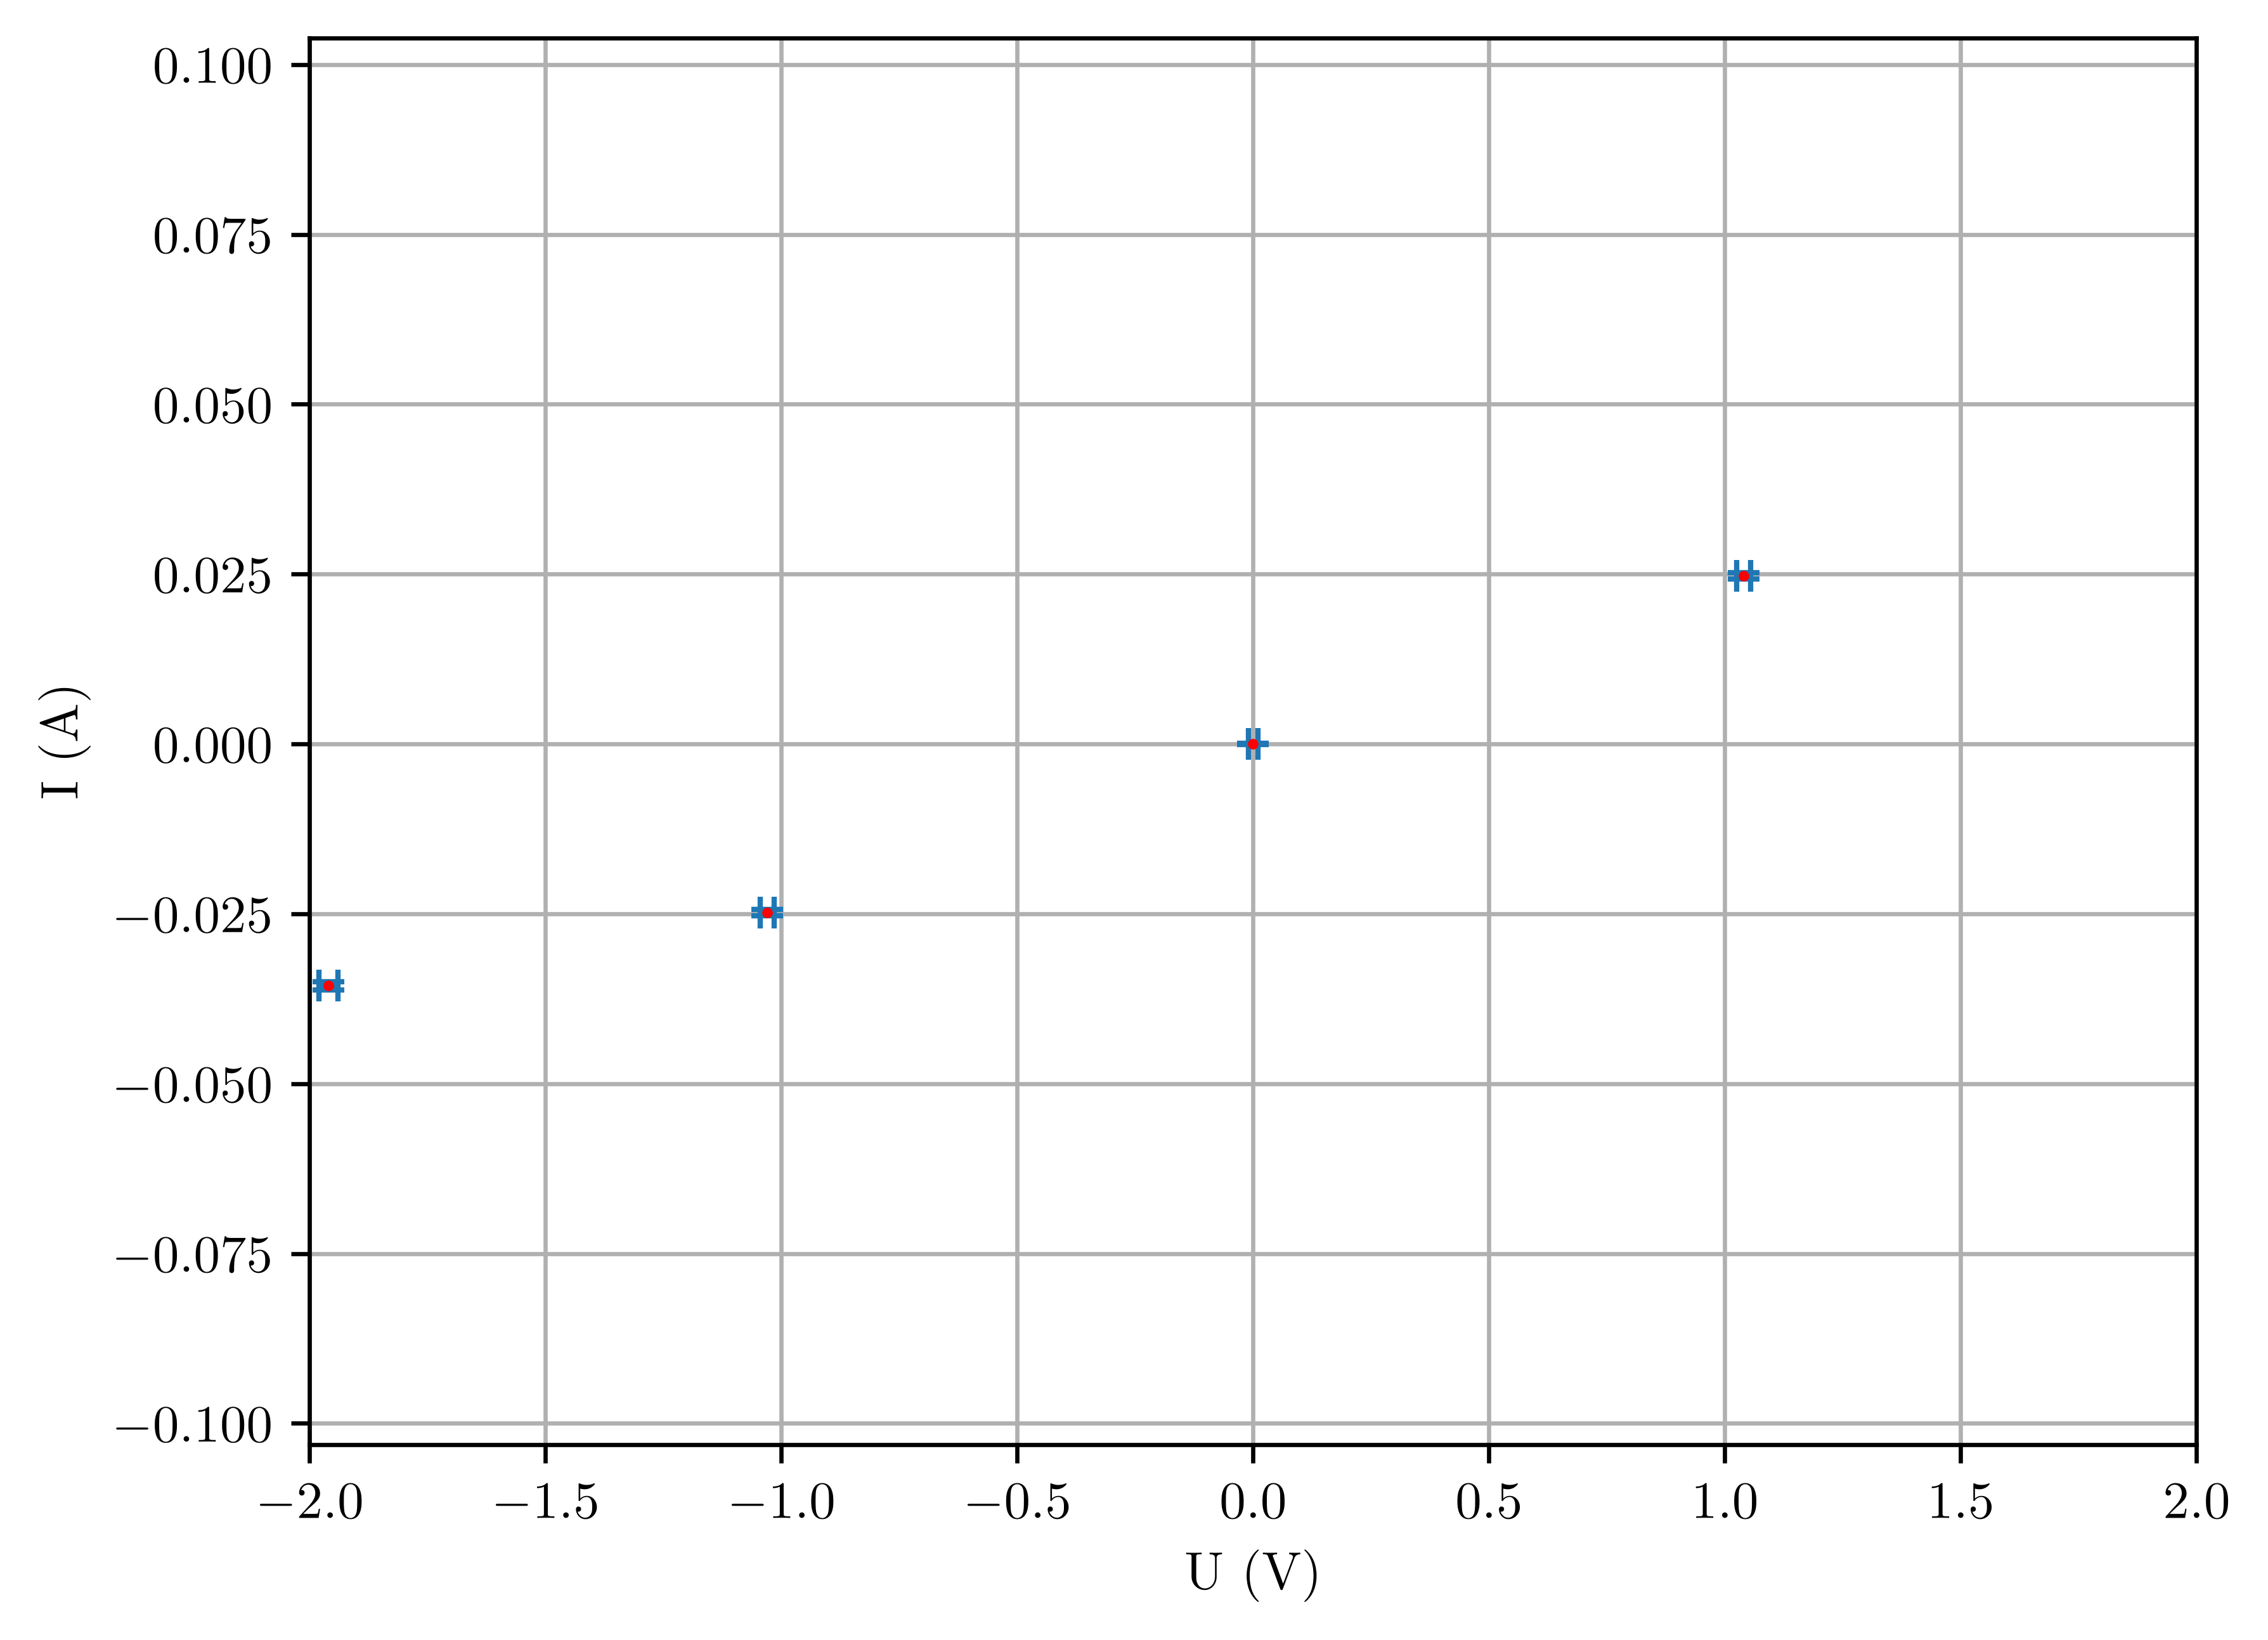

C:\Users\oskar\AppData\Local\Temp\ipykernel_4436\814896545.py:21: RuntimeWarning: invalid value encountered in multiply
  omega_bar_w = (np.sum(w*omega)) / (np.sum(w))


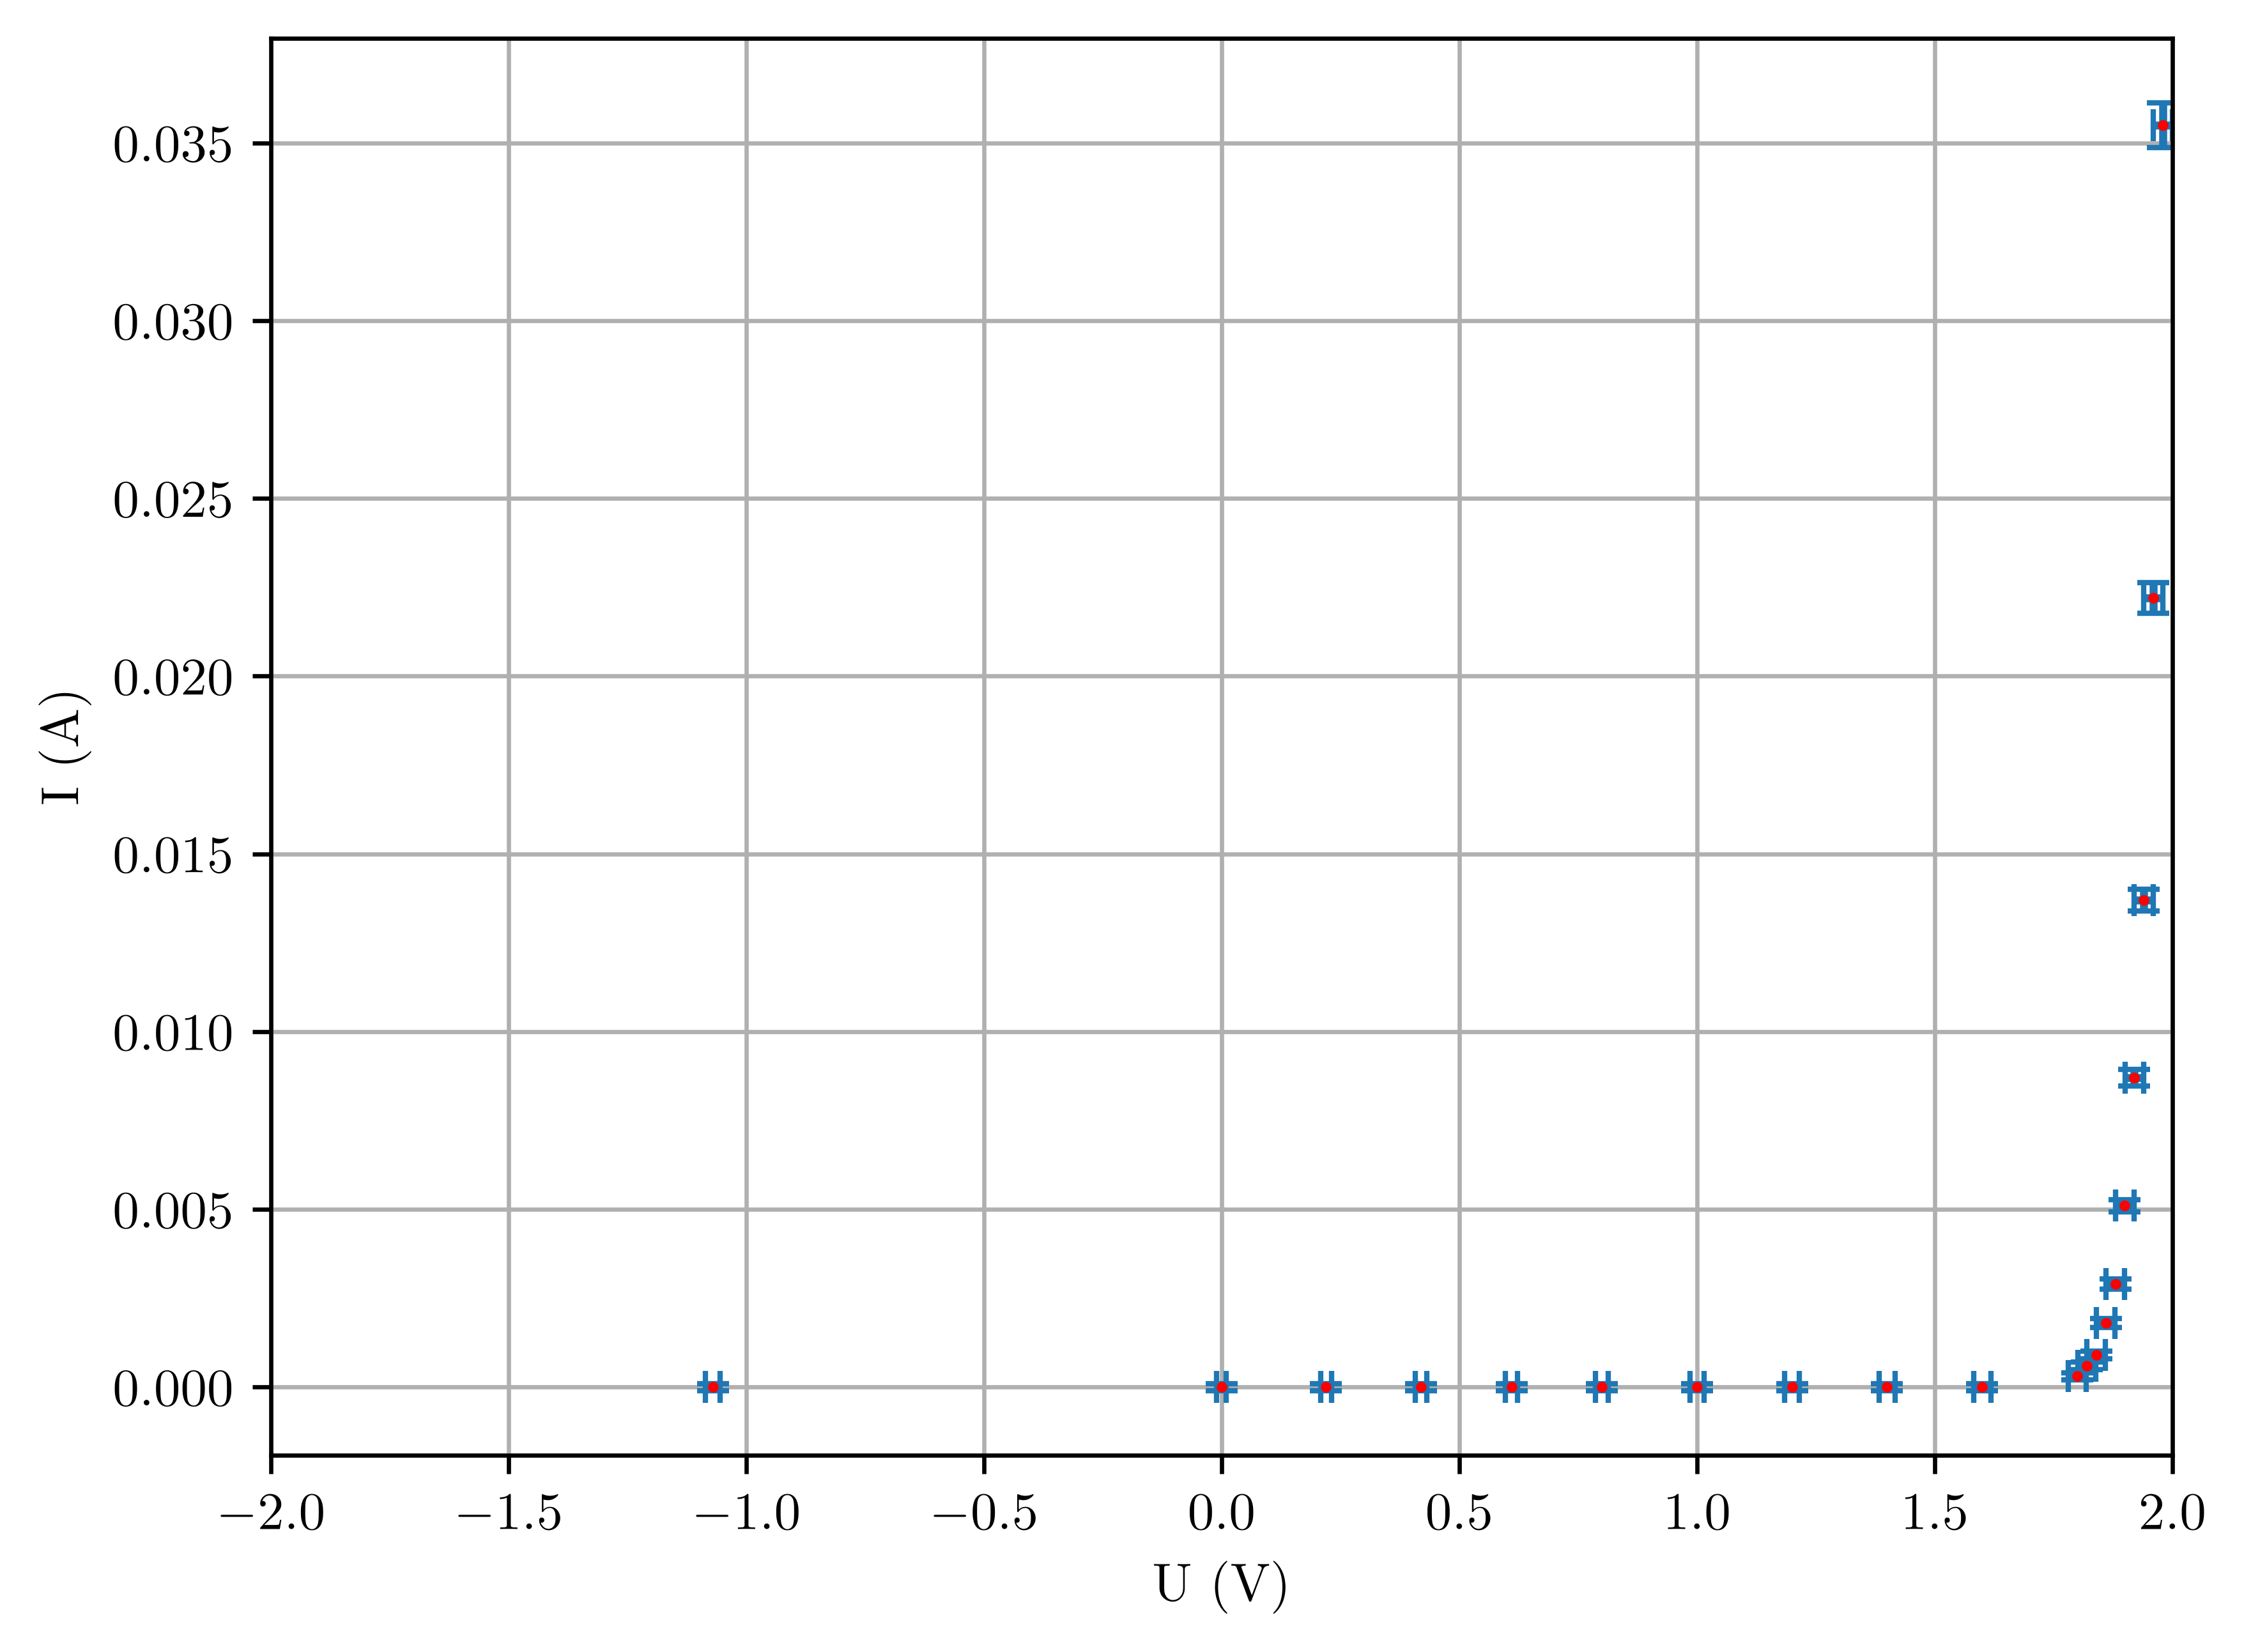

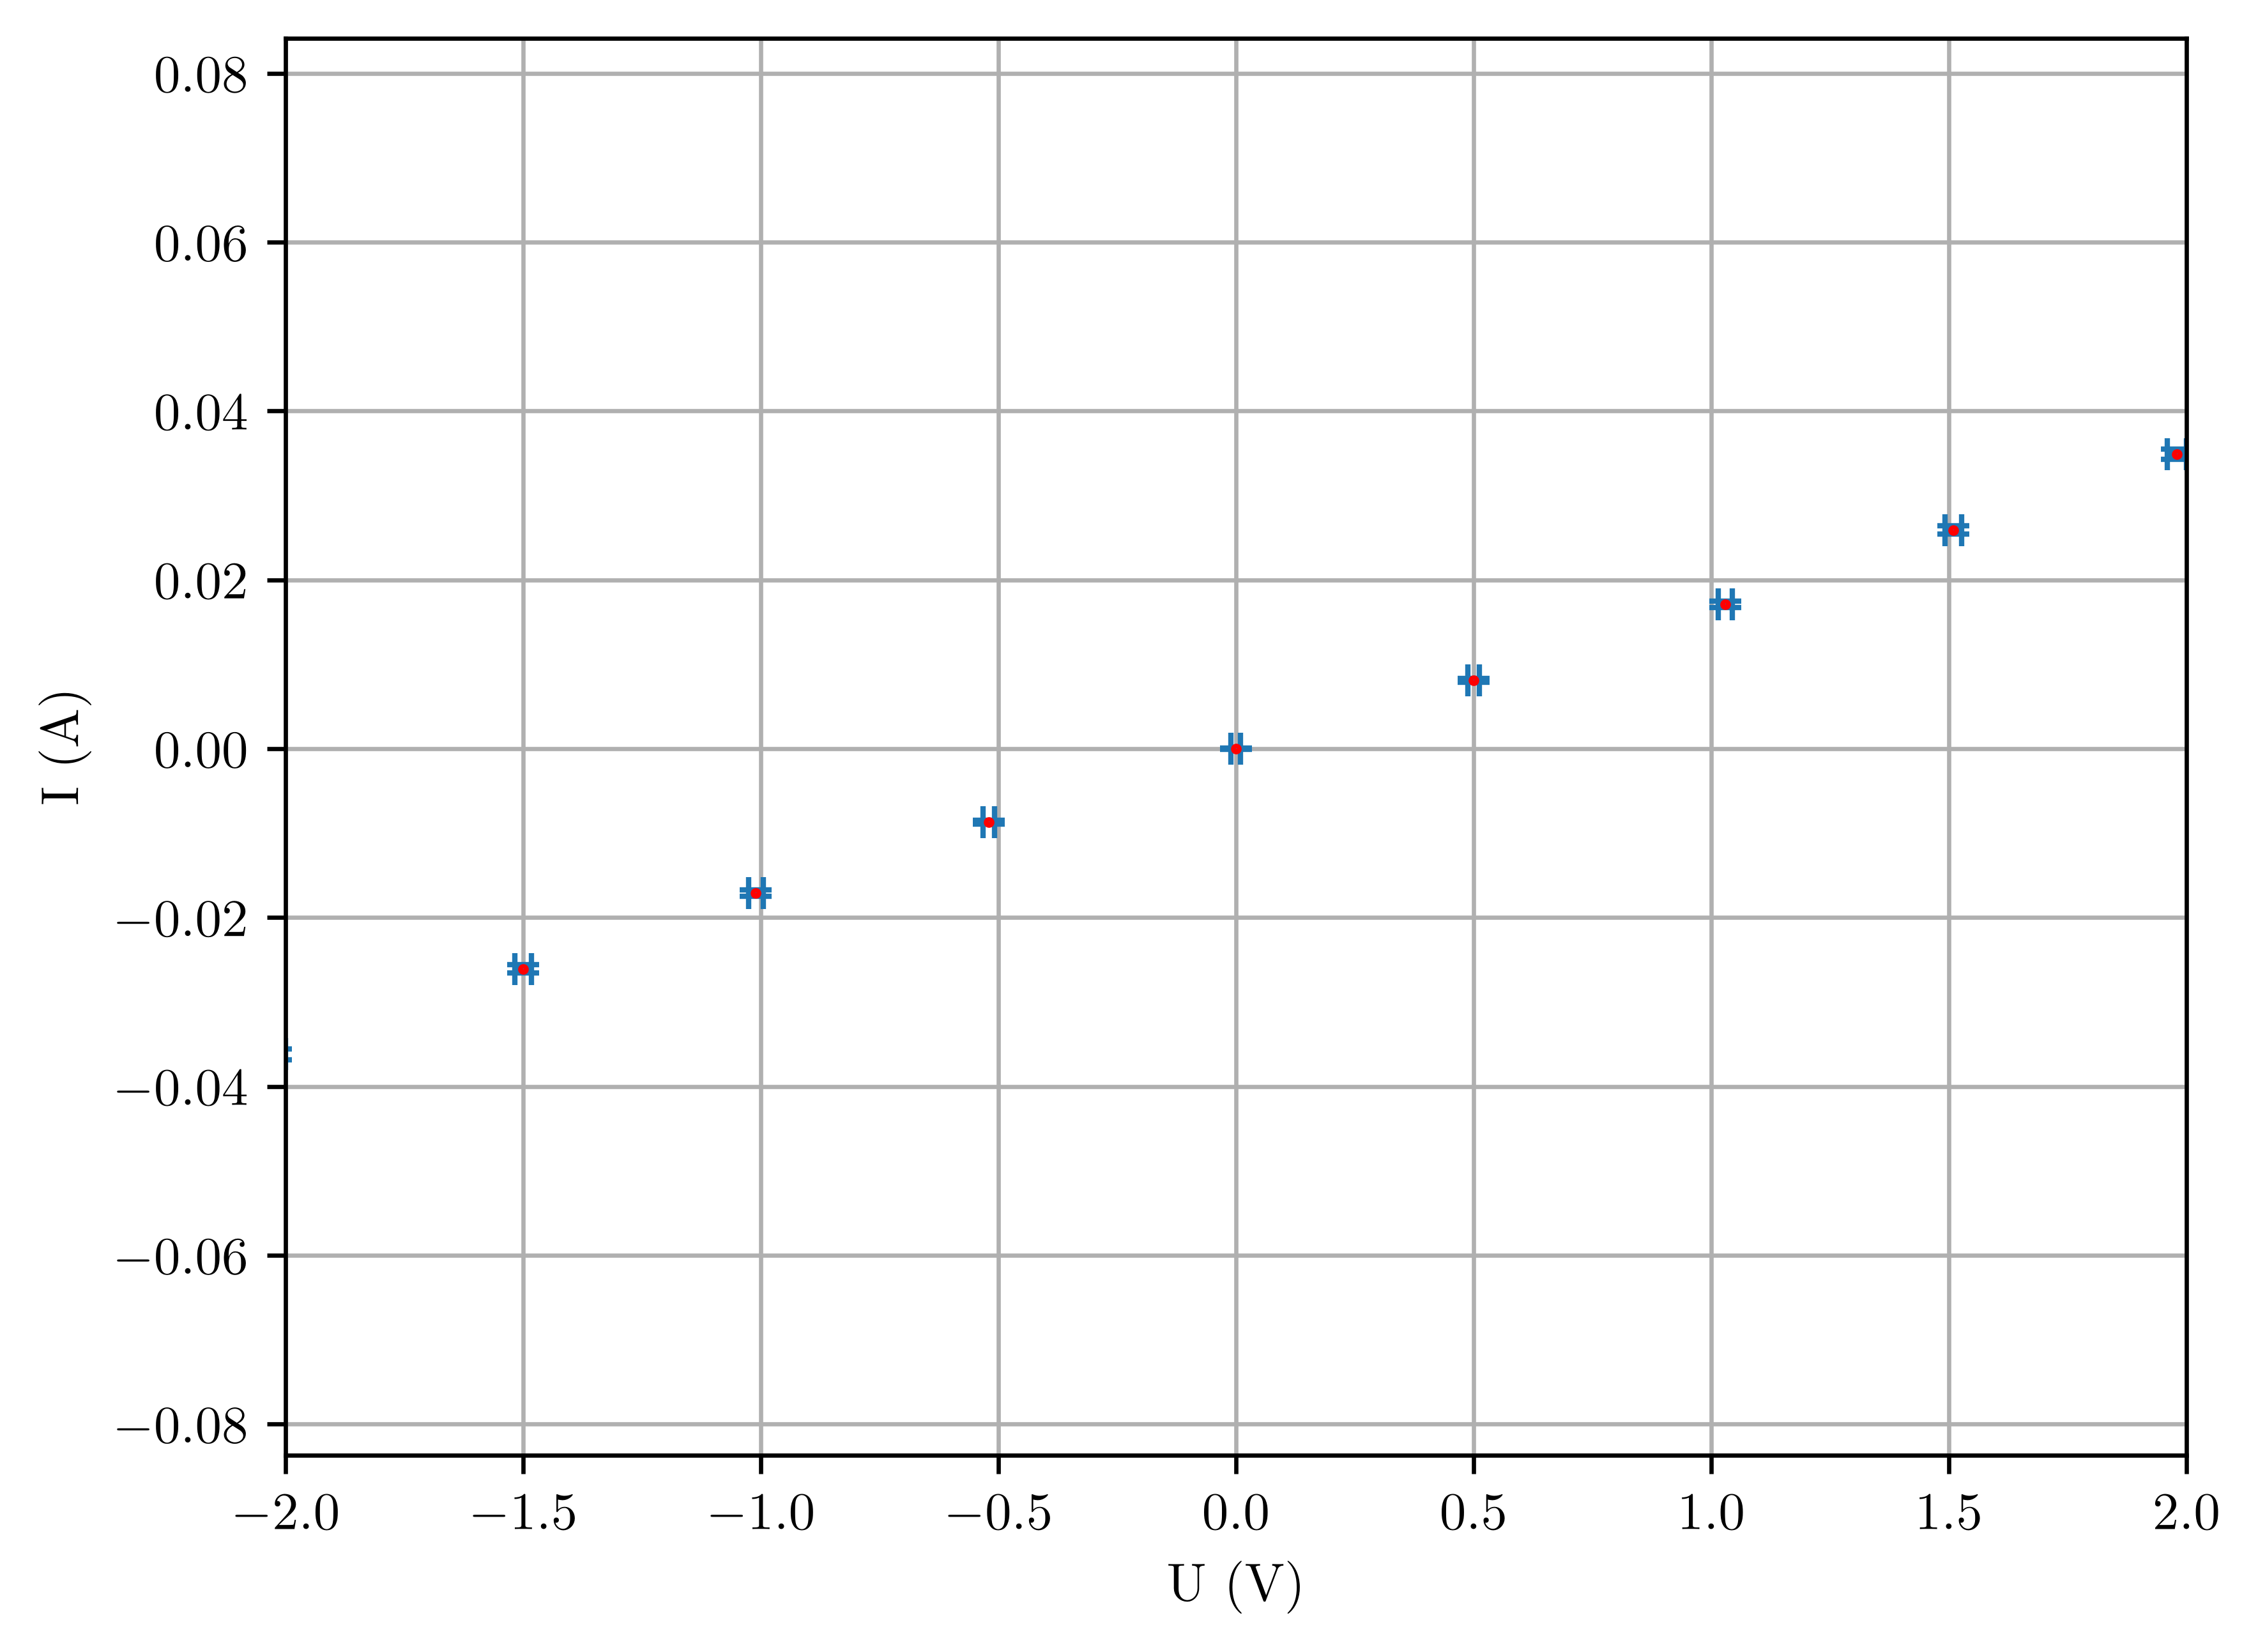

In [ ]:
# Laden und Ordnen der Daten
for sheet in range(1,5):
    messdaten = pd.read_excel("V45.xlsx", sheet_name="Messung"+str(sheet))
    messdaten = messdaten.drop(columns=["Einstellungen"])
    messdaten["I(A)"] = messdaten["I(mA)"] * 0.001
    messdaten.sort_values(by="U(V)", inplace=True)  # Sortiere die Daten nach Spannung

    # Wiederstand berechnen
    messdaten[r"Widerstand ($\Omega$)"] = messdaten["U(V)"] / messdaten["I(A)"]  # Berechne den Widerstand

    # Fehler berechnen
    messdaten[r"$\Delta U$"] = messdaten["U(V)"].abs() * 0.005 + 0.01
    messdaten[r"$\Delta I$"] = messdaten["I(A)"].abs() * 0.015 + 0.1e-3
    messdaten[r"$\Delta \Omega$"] = np.sqrt((messdaten[r"$\Delta U$"]/messdaten["I(A)"])**2 + ((messdaten["U(V)"] * messdaten[r"$\Delta I$"])/(messdaten["I(A)"]**2))**2)

    # Gewichteter Mittelwert 
    messdaten_NN = messdaten[pd.notna(messdaten)] # Messdaten bereinigen 
    messdaten_NN = messdaten_NN[messdaten_NN["Widerstand ($\\Omega$)"] != 0]  # Nullen löschen
    w = 1/(messdaten_NN[r"$\Delta \Omega$"].to_numpy())**2
    omega = messdaten_NN[r"Widerstand ($\Omega$)"].to_numpy()
    omega_bar_w = (np.sum(w*omega)) / (np.sum(w))
    del_omega_bar_w = 1 / np.sqrt(np.sum(w)) # Fehler

    # print("Messung ", sheet, end=' ')
    # print("Mittler gewichteter Wiederstand ", omega_bar_w, end=' ')
    # print("Fehler d. Wiedrstandes: ", del_omega_bar_w)

    if False: # Tabellen Printen
        cols = ['U(V)', r'$\Delta U$', 'I(A)', r'$\Delta I$'] #, 'Widerstand ($\Omega$)', r'$\Delta \Omega$']
        # messdaten_tex = messdaten.drop(columns=['Wiederstand'])[cols]
        messdaten_tex = messdaten[cols]
        print(generate_Table(messdaten_tex, "Messreihe " + str(sheet), "Messreihe"+str(sheet)))

    # Plotten
    if True:
        fig, ax = plt.subplots(dpi=600)
        ax.errorbar(messdaten["U(V)"], messdaten["I(A)"], xerr=messdaten[r"$\Delta U$"], yerr=messdaten[r"$\Delta I$"], fmt=',', capsize=3)
        ax.plot(messdaten["U(V)"], messdaten["I(A)"], '.', label="Messung " + str(sheet), color="red", markersize=2)

        ax.set_xlabel(r"U (V)")
        ax.set_ylabel(r"I (A)")

        ax.set_xlim(-2, 2)
        # ax.set_ylim(-1, 20)
        # ax.hlines(y=0, xmin=min(messdaten["U(V)"]), xmax=max(messdaten["U(V)"]), colors="k")
        # ax.vlines(x=0, ymin=min(messdaten["I(A)"]), ymax=max(messdaten["I(A)"]), colors="k")

        # ax.legend()
        ax.grid()
        plt.show()

        # messdaten.plot(x=r"U(V)", y=r"I(A)", kind="scatter", legend=True, grid=True)

Steigung:  0.006902648135999163
Widerstand:  144.87193614646696
Steigungsfehler Messung Widerstand:  4.3599658080982185e-05
Fehler Widerstand: 0.9150642995366219


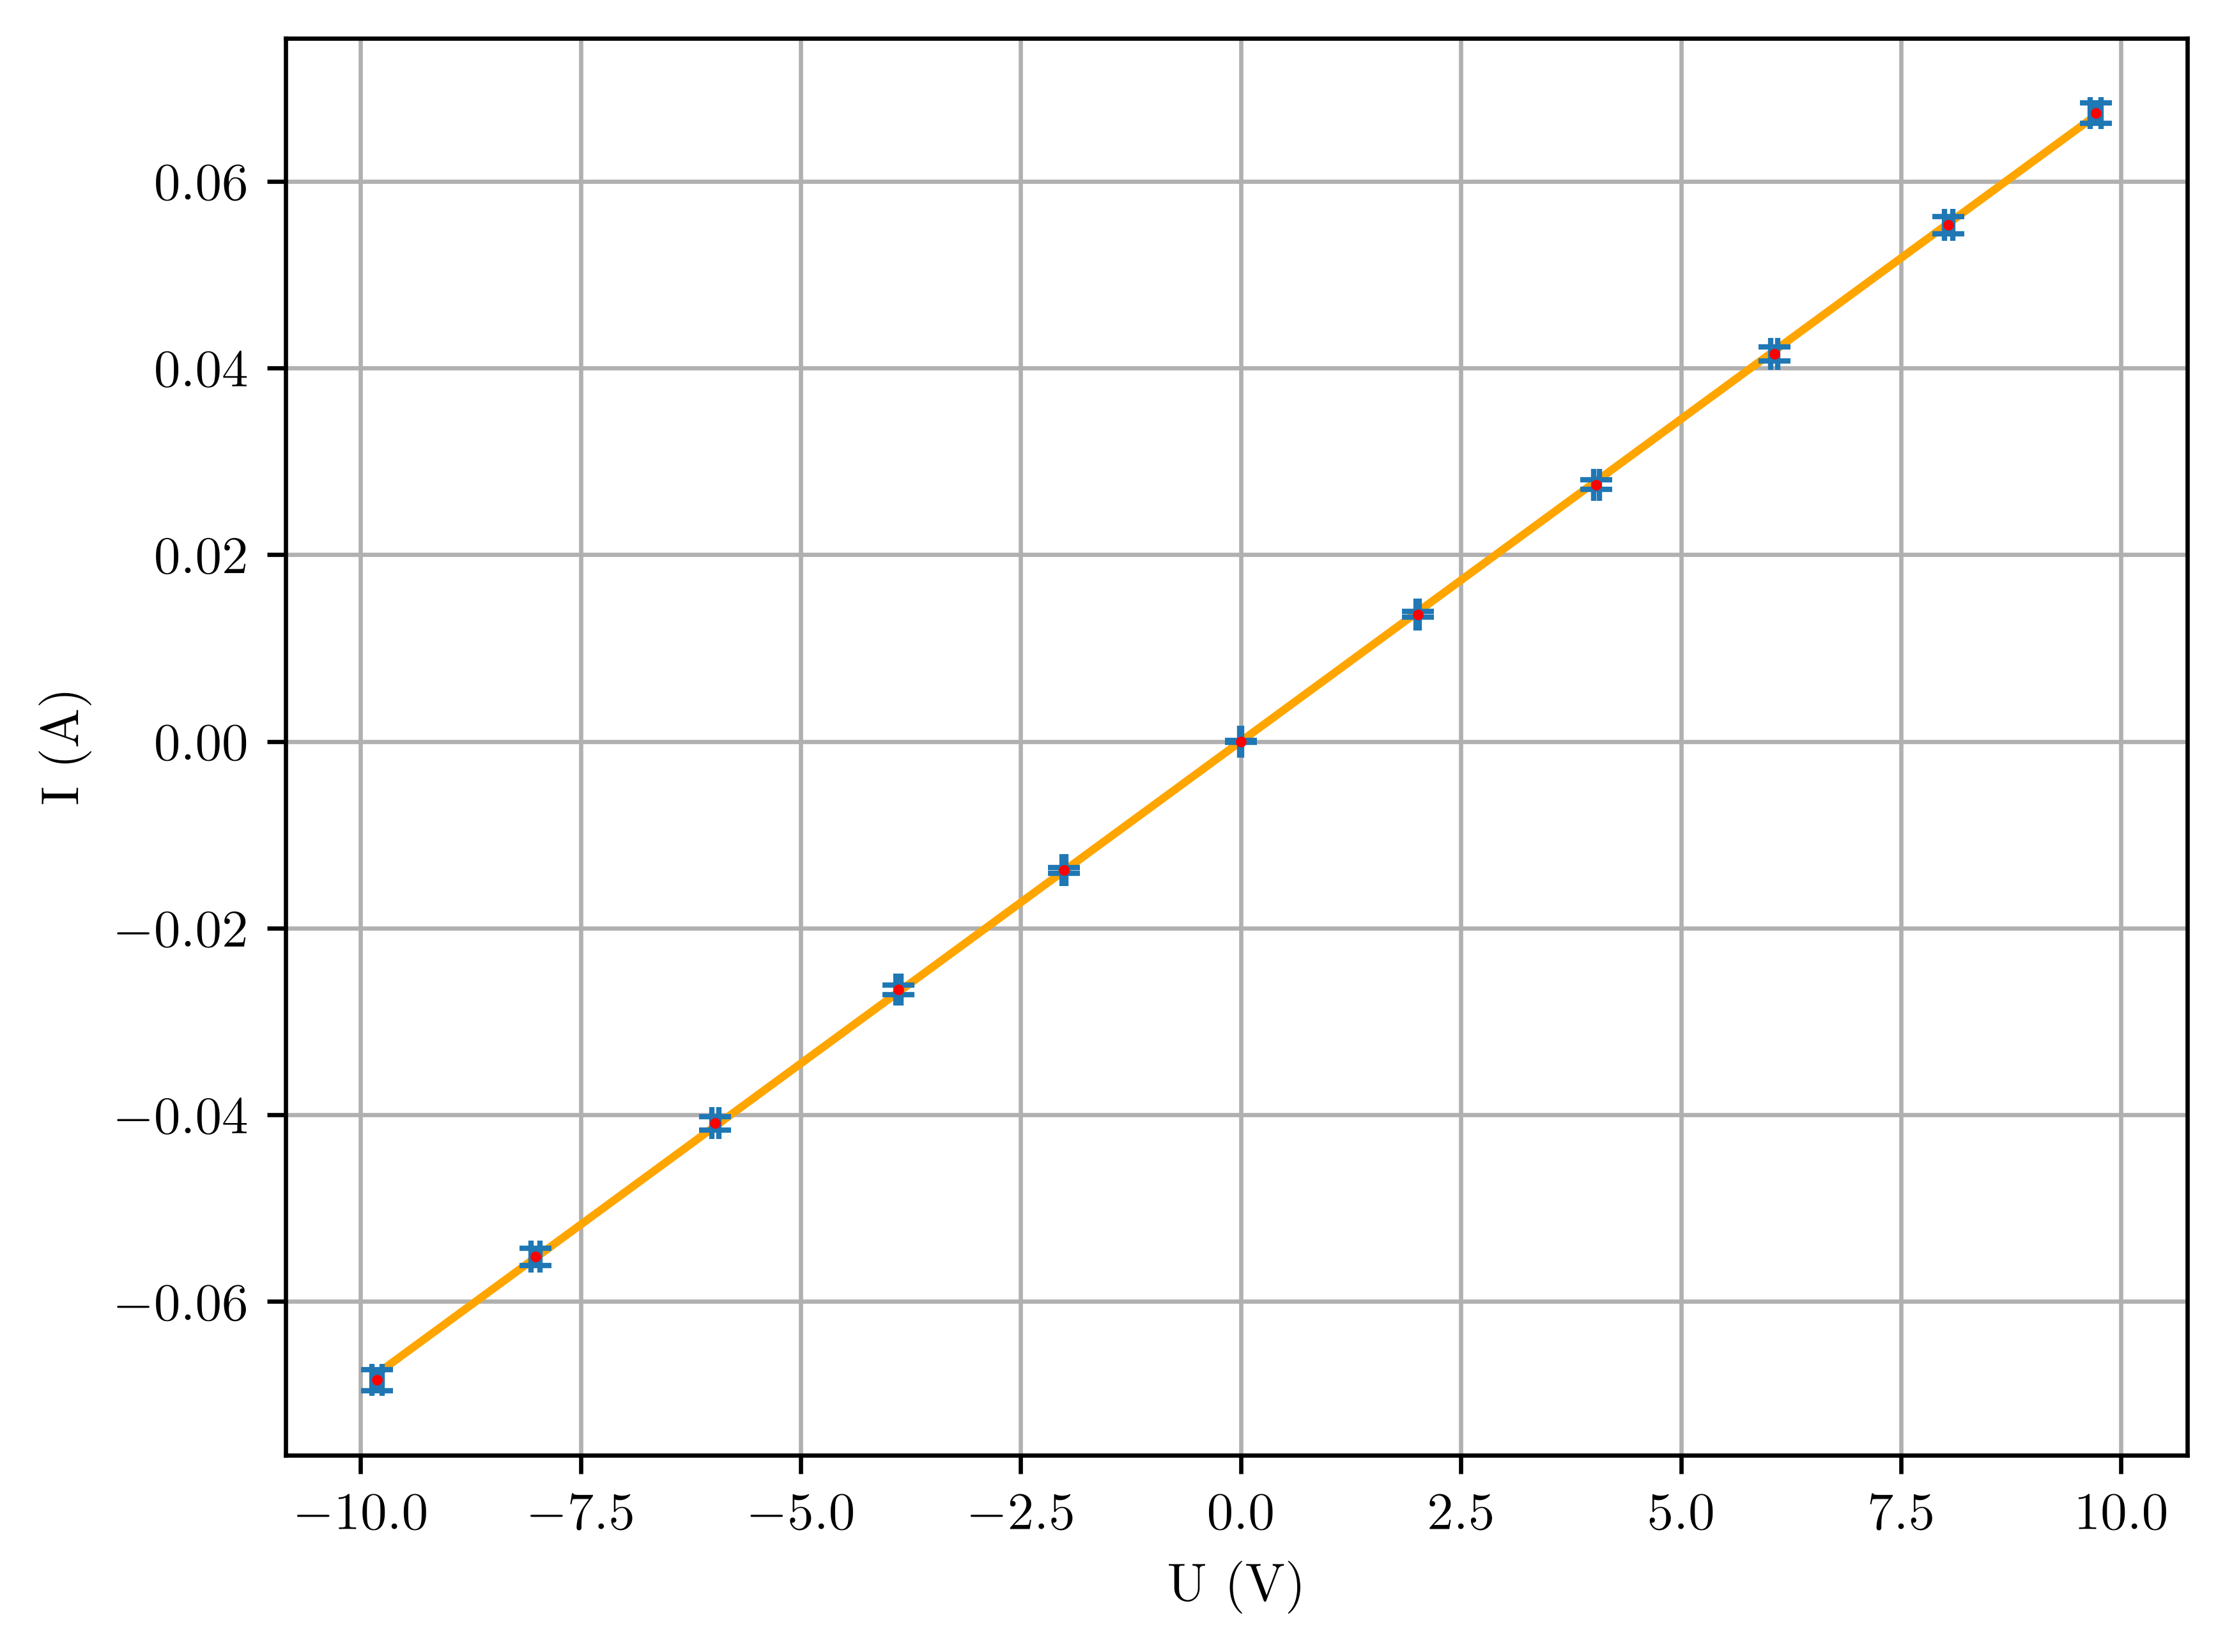

In [ ]:
# Ausgleichsgerade Plotten Messung 1
messdaten = pd.read_excel("V45.xlsx", sheet_name="Messung1")
messdaten["I(A)"] = messdaten["I(mA)"] * 0.001
messdaten = messdaten.drop(columns=["Einstellungen"])

# Fehler berechnen
messdaten[r"$\Delta U$"] = messdaten["U(V)"].abs() * 0.005 + 0.01
messdaten[r"$\Delta I$"] = messdaten["I(A)"].abs() * 0.015 + 0.1e-3

# Lin fit machen 
werte_Gerade = np.array([np.min(messdaten["U(V)"]), np.max(messdaten["U(V)"])])
steigung = b_simpel(messdaten["U(V)"], messdaten["I(A)"])
print("Steigung: ", steigung)
print("Widerstand: ", steigung**(-1))

# Fehler aus lin fit berechnen
s = Streuung_simpel(messdaten["U(V)"].abs(), messdaten["I(A)"].abs())
steigungs_fehler = delta_b(messdaten["U(V)"].abs(), s)
print("Steigungsfehler Messung Widerstand: " , steigungs_fehler) 
Widerstand_fehler = steigungs_fehler/(steigung**2)
print("Fehler Widerstand:",Widerstand_fehler)


# Plotten 
fig, ax = plt.subplots(dpi=600)
ax.plot(werte_Gerade, werte_Gerade*(steigung) , color="orange")
ax.errorbar(messdaten["U(V)"], messdaten["I(A)"], xerr=messdaten[r"$\Delta U$"], yerr=messdaten[r"$\Delta I$"], fmt=',', capsize=3)
ax.plot(messdaten["U(V)"], messdaten["I(A)"], '.', label="Messung " + str(sheet), color="red", markersize=2)

ax.set_xlabel(r"U (V)")
ax.set_ylabel(r"I (A)")
ax.grid()
plt.show()


>=5.5: 
a =  0.032663374907632735
b =  0.006215656418639176
Widerstand:  160.88405353314798
Steigungsfehler Messung Widerstand:  4.560927836661771e-05
Wiederstand fehler 1.1805359061255307

<=-5.5: 
a =  -0.032038892770220394
b =  0.006197322337748907
Widerstand:  161.3600109048445
Steigungsfehler Messung Widerstand:  2.7941886833819998e-05
fehler Widerstand  0.7275243917431686

<= 2.5 & >= -2.5: 
a =  -0.00016862106234139383
b =  0.019288816396337196
Widerstand:  51.84351281346079
Steigungsfehler Messung Widerstand:  0.001211686624818871
Fehler Widerstand  3.256710508770506


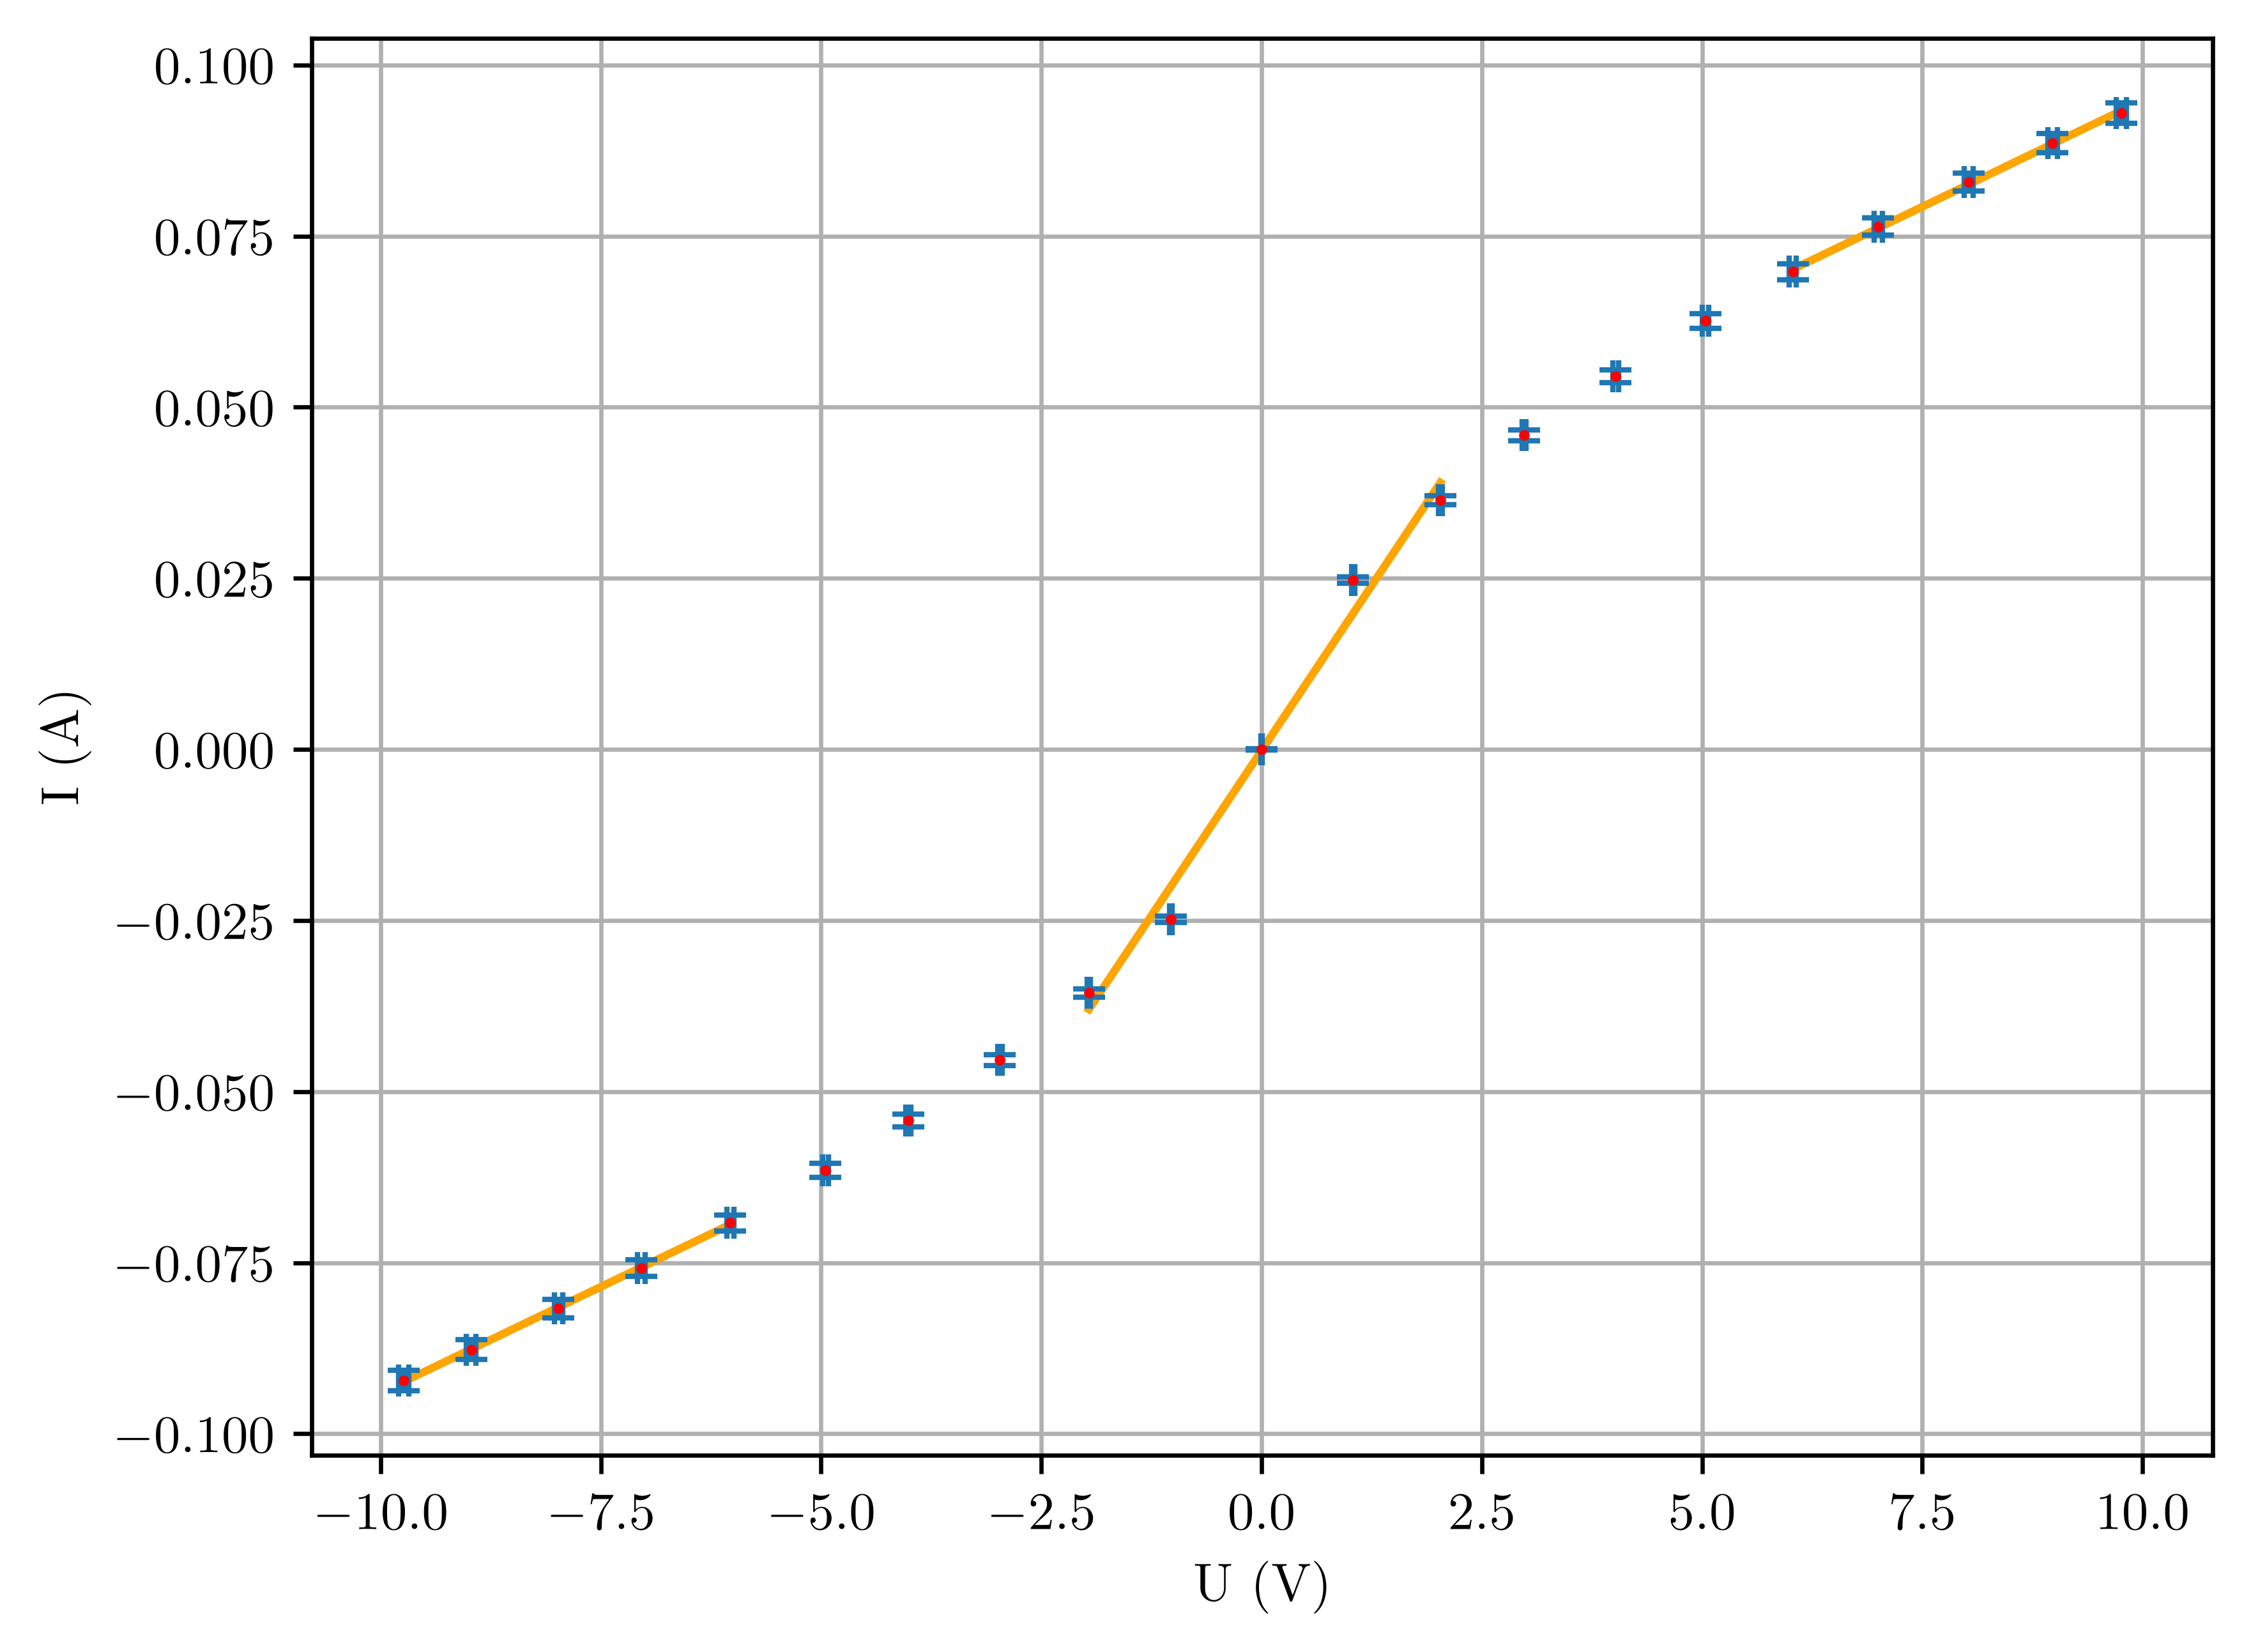

In [ ]:
# Ausgleichsgerade Plotten Messung 1
messdaten = pd.read_excel("V45.xlsx", sheet_name="Messung2")
messdaten = messdaten.drop(columns=["Einstellungen"])
messdaten.sort_values(by="U(V)", inplace=True)  # Sortiere die Daten nach Spannung
messdaten["I(A)"] = messdaten["I(mA)"] * 0.001

# Fehler berechnen
messdaten[r"$\Delta U$"] = messdaten["U(V)"].abs() * 0.005 + 0.01
messdaten[r"$\Delta I$"] = messdaten["I(A)"].abs() * 0.015 + 0.1e-3

# letzte gerade 
messdaten_Teil1 = messdaten[messdaten["U(V)"] >= 5.5]
werte_Gerade_Teil1 = np.array([np.min(messdaten_Teil1["U(V)"]), np.max(messdaten_Teil1["U(V)"])])
a1 = a_hat(messdaten_Teil1["U(V)"], messdaten_Teil1["I(A)"])
b1 = b_hat(messdaten_Teil1["U(V)"], messdaten_Teil1["I(A)"])

print("\n>=5.5: ")
print("a = ", a1)
print("b = ", b1)
print("Widerstand: ", b1**(-1))
# Fehler aus lin fit berechnen
s = Streuung(messdaten_Teil1["U(V)"], messdaten_Teil1["I(A)"])
db = delta_b(messdaten_Teil1["U(V)"], s)
print("Steigungsfehler Messung Widerstand: " , db)
fehler_wiederstand2 = db/(b1**2)
print("Wiederstand fehler", fehler_wiederstand2)


# erste gerade 
messdaten_Teil2 = messdaten[messdaten["U(V)"] <= -5.5]
werte_Gerade_Teil2 = np.array([np.min(messdaten_Teil2["U(V)"]), np.max(messdaten_Teil2["U(V)"])])
a2 = a_hat(messdaten_Teil2["U(V)"], messdaten_Teil2["I(A)"])
b2 = b_hat(messdaten_Teil2["U(V)"], messdaten_Teil2["I(A)"])

print("\n<=-5.5: ")
print("a = ", a2)
print("b = ", b2)
print("Widerstand: ", b2**(-1))
# Fehler aus lin fit berechnen
s = Streuung(messdaten_Teil2["U(V)"].abs(), messdaten_Teil2["I(A)"].abs())
db =  delta_b(messdaten_Teil2["U(V)"].abs(), s)
print("Steigungsfehler Messung Widerstand: " , db) 
fehler_wiederstand3 = db/(b2**2)
print("fehler Widerstand ", fehler_wiederstand3)

# mittlere gerade 
messdaten_Teil3 = messdaten[messdaten["U(V)"] <= 2.5]
messdaten_Teil3 = messdaten_Teil3[messdaten_Teil3["U(V)"] >= -2.5]
werte_Gerade_Teil3 = np.array([np.min(messdaten_Teil3["U(V)"]), np.max(messdaten_Teil3["U(V)"])])
a3 = a_hat(messdaten_Teil3["U(V)"], messdaten_Teil3["I(A)"])
b3 = b_hat(messdaten_Teil3["U(V)"], messdaten_Teil3["I(A)"])

print("\n<= 2.5 & >= -2.5: ")
print("a = ", a3)
print("b = ", b3)
print("Widerstand: ", b3**(-1))
# Fehler aus lin fit berechnen
s = Streuung((messdaten_Teil3["U(V)"].abs()), (messdaten_Teil3["I(A)"].abs()))
db = delta_b((messdaten_Teil3["U(V)"].abs()), s)
print("Steigungsfehler Messung Widerstand: " , db)
fehler_wiederstand4 = db/(b3**2)
print("Fehler Widerstand ", fehler_wiederstand4)

# Plotten 
fig, ax = plt.subplots(dpi=600)
ax.plot(werte_Gerade_Teil1, werte_Gerade_Teil1*(b1)+a1 , color="orange")
ax.plot(werte_Gerade_Teil2, werte_Gerade_Teil2*(b2)+a2 , color="orange")
ax.plot(werte_Gerade_Teil3, werte_Gerade_Teil3*(b3)+a3 , color="orange")

ax.errorbar(messdaten["U(V)"], messdaten["I(A)"], xerr=messdaten[r"$\Delta U$"], yerr=messdaten[r"$\Delta I$"], fmt=',', capsize=3)
ax.plot(messdaten["U(V)"], messdaten["I(A)"], '.', label="Messung " + str(sheet), color="red", markersize=2)

ax.set_xlabel(r"U (V)")
ax.set_ylabel(r"I (A)")
ax.grid()
plt.show()